<a href="https://colab.research.google.com/github/expe-rience/AIML-Case-Study/blob/main/AIML_Case_Study_CO2_Emmision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **CO2 Emission Case Study**

**Problem statement:**  
The Global Automotive Council aims to understand the key factors influencing vehicle CO₂ emissions and explore data-driven strategies for emission reduction.  
A dataset containing detailed information on vehicle specifications, engine characteristics, fuel types, and emission levels has been provided.  
The objective is to analyze this dataset to uncover hidden patterns, identify the major contributors to CO₂ emissions, and develop predictive models to support policy and design decisions in the automotive sector.  
**Dataset link:** [*Link*](https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/158/208/original/CO2_Emissions.csv?1760012266)

* To download the dataset  
  * Click the link above.  
  * Right-click on an empty area and select “Save As.”  
  * Choose your preferred download location, enter a relevant dataset name, add the “.csv” extension, and click Save.

**Dataset description: ***[Link*](https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/158/211/original/Dataset_Description.pdf?1760012364)  
**Approach Document:** [CO2 Case Study Approach Document](https://drive.google.com/open?id=1oQSwuoNtxXN2tiqV45GancgD9rzmHcri&usp=drive_copy)  
**Case Study Questions:**

1. Begin by familiarizing yourself with the dataset. Identify what kind of information is captured about vehicles and how these variables might influence CO₂ emissions.  
2. Examine the dataset for any inconsistencies, missing entries, or data quality issues. Consider what preprocessing steps may be necessary to make the dataset ready for meaningful analysis.  
3. Study the relationships between various vehicle features and CO₂ emissions. Which attributes appear to have stronger influence on emission levels? Use suitable methods to support your reasoning.  
4. Create visual summaries that reveal how emission levels change with respect to different numerical variables in the dataset. Focus on uncovering patterns or trends that might not be immediately visible.  
5. Compare emission levels across different vehicle types or fuel categories. Identify any clear distinctions or surprising findings that emerge.  
6. Observe if there are any vehicles that produce unusually high or low emissions compared to others with similar characteristics. Reflect on what could explain such deviations.  
7. Prepare the dataset for model building by ensuring that numerical and categorical features are appropriately represented. Consider any transformations or encodings that may improve interpretability.  
8. Develop a simple, interpretable model to estimate CO₂ emissions using relevant features from the dataset. Summarize how the model captures the relationship between vehicle characteristics and emissions.  
9. Assess how well the model performs in estimating emissions. Reflect on the meaning of the performance metrics and what they indicate about model reliability.  
10. Based on the analysis and model findings, summarize which factors most strongly influence CO₂ emissions and suggest how such insights could support emission reduction efforts.







**Importing All Python Libararies for this activity**

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, KFold

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LinearRegression, Ridge, Lasso

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings("ignore")

import os

1. Begin by familiarizing ourself with the dataset. Identify what kind of information is captured about vehicles and how these variables might influence CO₂ emissions.

In [ ]:
!wget -O CO2_Emissions.csv "https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/158/208/original/CO2_Emissions.csv?1760012266"


--2026-09-29 16:31:54--  https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/158/208/original/CO2_Emissions.csv?1760012266
Resolving d2beiqkhq929f0.cloudfront.net (d2beiqkhq929f0.cloudfront.net)... 3.170.7.168, 3.170.7.76, 3.170.7.158, ...
Connecting to d2beiqkhq929f0.cloudfront.net (d2beiqkhq929f0.cloudfront.net)|3.170.7.168|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 476091 (465K) [text/plain]
Saving to: ‘CO2_Emissions.csv’

CO2_Emissions.csv   100%[===================>] 464.93K  --.-KB/s    in 0.007s  

2026-09-29 16:31:54 (62.5 MB/s) - ‘CO2_Emissions.csv’ saved [476091/476091]



In [ ]:
cars=pd.read_csv("CO2_Emissions.csv")
cars.head()



,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


### Observation — Q1

- The dataset contains **7,385 vehicle records and 12 variables** covering manufacturer, model, vehicle class, engine characteristics, transmission, fuel type, fuel consumption and CO₂ emissions.
- `CO2 Emissions(g/km)` is the **target variable** for this case study.
- Before modeling, we should distinguish between **numerical predictors** (for example, engine size, cylinders and fuel consumption) and **categorical predictors** (for example, vehicle class, transmission and fuel type).
- Our initial hypothesis is that engine characteristics and fuel consumption will be strongly associated with CO₂ emissions. We will test this rather than assume it.

Q2 — Data Quality

In [ ]:
print("\nShape of the DataFrame:")
print(cars.shape)

print("\nDataFrame information:")
cars.info()


Shape of the DataFrame:
(7385, 12)

DataFrame information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7385 entries, 0 to 7384
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Make                              7385 non-null   object 
 1   Model                             7385 non-null   object 
 2   Vehicle Class                     7385 non-null   object 
 3   Engine Size(L)                    7385 non-null   float64
 4   Cylinders                         7385 non-null   int64  
 5   Transmission                      7385 non-null   object 
 6   Fuel Type                         7385 non-null   object 
 7   Fuel Consumption City (L/100 km)  7385 non-null   float64
 8   Fuel Consumption Hwy (L/100 km)   7385 non-null   float64
 9   Fuel Consumption Comb (L/100 km)  7385 non-null   float64
 10  Fuel Consumption Comb (mpg)       7385 non-null   int64  
 11  CO2 Emiss

### Observation — Q2

- The dataset contains **7,385 rows and 12 columns**.
- All 12 columns have **7,385 non-null values**, so there are no missing entries.
- There are **7 numerical columns** and **5 categorical/text columns**. Numerical variables can be used directly by regression models, while categorical variables will need encoding.
- The data-quality checks therefore show no missing-value problem, but duplicate records require further investigation.

In [ ]:
print("Duplicate rows:")
print(cars.duplicated().sum())



Duplicate rows:
1103


In [ ]:
duplicate_rows = cars[cars.duplicated(keep=False)]

print("Number of duplicate records:", len(duplicate_rows))

duplicate_rows.head(20)

Number of duplicate records: 2102


,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244
5,ACURA,RLX,MID-SIZE,3.5,6,AS6,Z,11.9,7.7,10.0,28,230
12,ALFA ROMEO,4C,TWO-SEATER,1.8,4,AM6,Z,9.7,6.9,8.4,34,193
13,ASTON MARTIN,DB9,MINICOMPACT,5.9,12,A6,Z,18.0,12.6,15.6,18,359
15,ASTON MARTIN,V8 VANTAGE,TWO-SEATER,4.7,8,AM7,Z,17.4,11.3,14.7,19,338
17,ASTON MARTIN,V8 VANTAGE S,TWO-SEATER,4.7,8,AM7,Z,17.4,11.3,14.7,19,338
27,AUDI,A6 QUATTRO,MID-SIZE,3.0,6,AS8,Z,12.8,8.6,10.9,26,251
28,AUDI,A6 QUATTRO TDI (modified),MID-SIZE,3.0,6,AS8,D,9.8,6.2,8.1,35,217
30,AUDI,A7 QUATTRO TDI (modified),MID-SIZE,3.0,6,AS8,D,9.8,6.2,8.1,35,217
33,AUDI,A8 TDI (modified),MID-SIZE,3.0,6,AS8,D,9.8,6.5,8.4,34,224


In [ ]:
duplicate_counts = (
    cars.value_counts()
    .reset_index(name="Count")
)

duplicate_counts.head(20)

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km),Count
0,LEXUS,GS F,COMPACT,5.0,8,AS8,Z,14.9,9.7,12.5,23,293,5
1,LEXUS,RC F,SUBCOMPACT,5.0,8,AS8,Z,15.2,9.5,12.6,22,289,4
2,TOYOTA,86,MINICOMPACT,2.0,4,AS6,Z,9.9,7.3,8.7,32,204,4
3,LEXUS,RX 350 AWD,SUV - SMALL,3.5,6,AS8,X,12.2,9.0,10.8,26,252,4
4,MITSUBISHI,RVR 4WD,SUV - SMALL,2.0,4,AV6,X,10.1,8.2,9.2,31,213,4
5,NISSAN,370Z,TWO-SEATER,3.7,6,AS7,Z,12.6,9.3,11.1,25,261,4
6,CHRYSLER,300,FULL-SIZE,3.6,6,A8,X,12.4,7.8,10.3,27,242,4
7,CHRYSLER,300 AWD,FULL-SIZE,3.6,6,A8,X,12.8,8.7,11.0,26,258,4
8,FIAT,500L,STATION WAGON - SMALL,1.4,4,A6,X,10.7,7.9,9.4,30,221,4
9,LEXUS,RX 450h AWD,SUV - STANDARD,3.5,6,AV6,Z,7.5,8.4,7.9,36,185,4


In [ ]:
duplicate_groups = (
    cars.groupby(list(cars.columns))
        .size()
        .reset_index(name="Count")
        .sort_values("Count", ascending=False)
)

duplicate_groups.head(20)

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km),Count
3927,LEXUS,GS F,COMPACT,5.0,8,AS8,Z,14.9,9.7,12.5,23,293,5
4010,LEXUS,RC F,SUBCOMPACT,5.0,8,AS8,Z,15.2,9.5,12.6,22,289,4
5715,TOYOTA,86,MINICOMPACT,2.0,4,AS6,Z,9.9,7.3,8.7,32,204,4
4014,LEXUS,RX 350 AWD,SUV - SMALL,3.5,6,AS8,X,12.2,9.0,10.8,26,252,4
4918,MITSUBISHI,RVR 4WD,SUV - SMALL,2.0,4,AV6,X,10.1,8.2,9.2,31,213,4
4925,NISSAN,370Z,TWO-SEATER,3.7,6,AS7,Z,12.6,9.3,11.1,25,261,4
1689,CHRYSLER,300,FULL-SIZE,3.6,6,A8,X,12.4,7.8,10.3,27,242,4
1697,CHRYSLER,300 AWD,FULL-SIZE,3.6,6,A8,X,12.8,8.7,11.0,26,258,4
1943,FIAT,500L,STATION WAGON - SMALL,1.4,4,A6,X,10.7,7.9,9.4,30,221,4
4019,LEXUS,RX 450h AWD,SUV - STANDARD,3.5,6,AV6,Z,7.5,8.4,7.9,36,185,4


In [ ]:
model_counts = (
    cars.groupby(["Make", "Model"])
        .size()
        .reset_index(name="Count")
        .sort_values("Count", ascending=False)
)

model_counts.head(20)

,Make,Model,Count
700,FORD,F-150 FFV,32
703,FORD,F-150 FFV 4X4,32
734,FORD,MUSTANG,27
718,FORD,FOCUS FFV,24
518,CHEVROLET,SONIC,20
519,CHEVROLET,SONIC 5,20
695,FORD,F-150 4X4,20
692,FORD,F-150,20
1981,VOLKSWAGEN,JETTA,19
1928,TOYOTA,TACOMA 4WD,19


In [ ]:
cars_no_duplicates = cars.drop_duplicates()

print("Original rows:", len(cars))
print("Rows after removing duplicates:", len(cars_no_duplicates))
print("Rows removed:", len(cars) - len(cars_no_duplicates))

Original rows: 7385
Rows after removing duplicates: 6282
Rows removed: 1103


In [ ]:
print("Original dataset:")
print(cars["CO2 Emissions(g/km)"].describe())

print("\nAfter removing exact duplicates:")
print(cars_no_duplicates["CO2 Emissions(g/km)"].describe())

Original dataset:
count    7385.000000
mean      250.584699
std        58.512679
min        96.000000
25%       208.000000
50%       246.000000
75%       288.000000
max       522.000000
Name: CO2 Emissions(g/km), dtype: float64

After removing exact duplicates:
count    6282.000000
mean      251.157752
std        59.290426
min        96.000000
25%       208.000000
50%       246.000000
75%       289.000000
max       522.000000
Name: CO2 Emissions(g/km), dtype: float64


In [ ]:
print("Original correlation:")
print(
    cars.select_dtypes(include=np.number)
        .corr()["CO2 Emissions(g/km)"]
        .sort_values(ascending=False)
)

print("\nCorrelation after removing duplicates:")
print(
    cars_no_duplicates.select_dtypes(include=np.number)
        .corr()["CO2 Emissions(g/km)"]
        .sort_values(ascending=False)
)

Original correlation:
CO2 Emissions(g/km)                 1.000000
Fuel Consumption City (L/100 km)    0.919592
Fuel Consumption Comb (L/100 km)    0.918052
Fuel Consumption Hwy (L/100 km)     0.883536
Engine Size(L)                      0.851145
Cylinders                           0.832644
Fuel Consumption Comb (mpg)        -0.907426
Name: CO2 Emissions(g/km), dtype: float64

Correlation after removing duplicates:
CO2 Emissions(g/km)                 1.000000
Fuel Consumption City (L/100 km)    0.918756
Fuel Consumption Comb (L/100 km)    0.916840
Fuel Consumption Hwy (L/100 km)     0.883424
Engine Size(L)                      0.854802
Cylinders                           0.834687
Fuel Consumption Comb (mpg)        -0.906783
Name: CO2 Emissions(g/km), dtype: float64


### Observation — Q2: Duplicate investigation

- The dataset contains **1,103 exact duplicate rows**.
- Exact duplicates are important because keeping repeated identical records can give that vehicle configuration more weight during statistical analysis and model training.
- We compared the dataset before and after removing exact duplicates. The CO₂ mean changes only slightly (**250.58 → 251.16 g/km**), while the correlation values also remain very similar.
- This suggests that the exact duplicates do **not materially change the overall relationships** in this dataset.
- For modeling, we can therefore use `cars_no_duplicates` to avoid giving identical records additional weight, while retaining the original `cars` dataset for reference.

In [ ]:
cars.describe()

,Engine Size(L),Cylinders,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
count,7385.000000,7385.000000,7385.000000,7385.000000,7385.000000,7385.000000,7385.000000
mean,3.160068,5.615030,12.556534,9.041706,10.975071,27.481652,250.584699
std,1.354170,1.828307,3.500274,2.224456,2.892506,7.231879,58.512679
min,0.900000,3.000000,4.200000,4.000000,4.100000,11.000000,96.000000
25%,2.000000,4.000000,10.100000,7.500000,8.900000,22.000000,208.000000
50%,3.000000,6.000000,12.100000,8.700000,10.600000,27.000000,246.000000
75%,3.700000,6.000000,14.600000,10.200000,12.600000,32.000000,288.000000
max,8.400000,16.000000,30.600000,20.600000,26.100000,69.000000,522.000000


### Observation — Q2

- The numerical variables show substantial variation across vehicle configurations.
- Engine size ranges from **0.9 L to 8.4 L**, and cylinders range from **3 to 16**.
- Combined fuel consumption ranges from **4.1 to 26.1 L/100 km**.
- CO₂ emissions range from **96 to 522 g/km**, indicating substantial variation that gives us enough spread to investigate the factors associated with emissions.
- These ranges also help identify observations that may deserve further investigation during outlier analysis.

In [ ]:
fuel_types = {
    "X": "Regular gasoline",
    "Z": "Premium gasoline",
    "D": "Diesel",
    "E": "Ethanol (E85)",
    "N": "Natural gas"
}

In [ ]:
cars.describe(include='O')

,Make,Model,Vehicle Class,Transmission,Fuel Type
count,7385,7385,7385,7385,7385
unique,42,2053,16,27,5
top,FORD,F-150 FFV,SUV - SMALL,AS6,X
freq,628,32,1217,1324,3637


### Observation — Q2: Categorical variables

- There are **42 makes, 2,053 models, 16 vehicle classes, 27 transmission categories and 5 fuel types**.
- `Model` has a very high number of unique categories. One-hot encoding it would create a large number of features and would make a simple, interpretable regression model harder to explain.
- We therefore have a strong reason to start the regression with broader categorical characteristics such as **Vehicle Class, Transmission and Fuel Type**, rather than individual Model.
- The final feature-selection decision should also consider the prediction objective and model performance.

In [ ]:
cars.isnull().sum()

,0
Make,0
Model,0
Vehicle Class,0
Engine Size(L),0
Cylinders,0
Transmission,0
Fuel Type,0
Fuel Consumption City (L/100 km),0
Fuel Consumption Hwy (L/100 km),0
Fuel Consumption Comb (L/100 km),0


### Observation — Q2

- All columns contain **zero missing values**.
- Therefore, missing-value imputation is not required.
- We can proceed to relationship analysis without dropping observations because of missing data.

Q3 — Feature Relationships

CO2 Emissions(g/km)                 1.000000
Fuel Consumption City (L/100 km)    0.919592
Fuel Consumption Comb (L/100 km)    0.918052
Fuel Consumption Hwy (L/100 km)     0.883536
Engine Size(L)                      0.851145
Cylinders                           0.832644
Fuel Consumption Comb (mpg)        -0.907426
Name: CO2 Emissions(g/km), dtype: float64


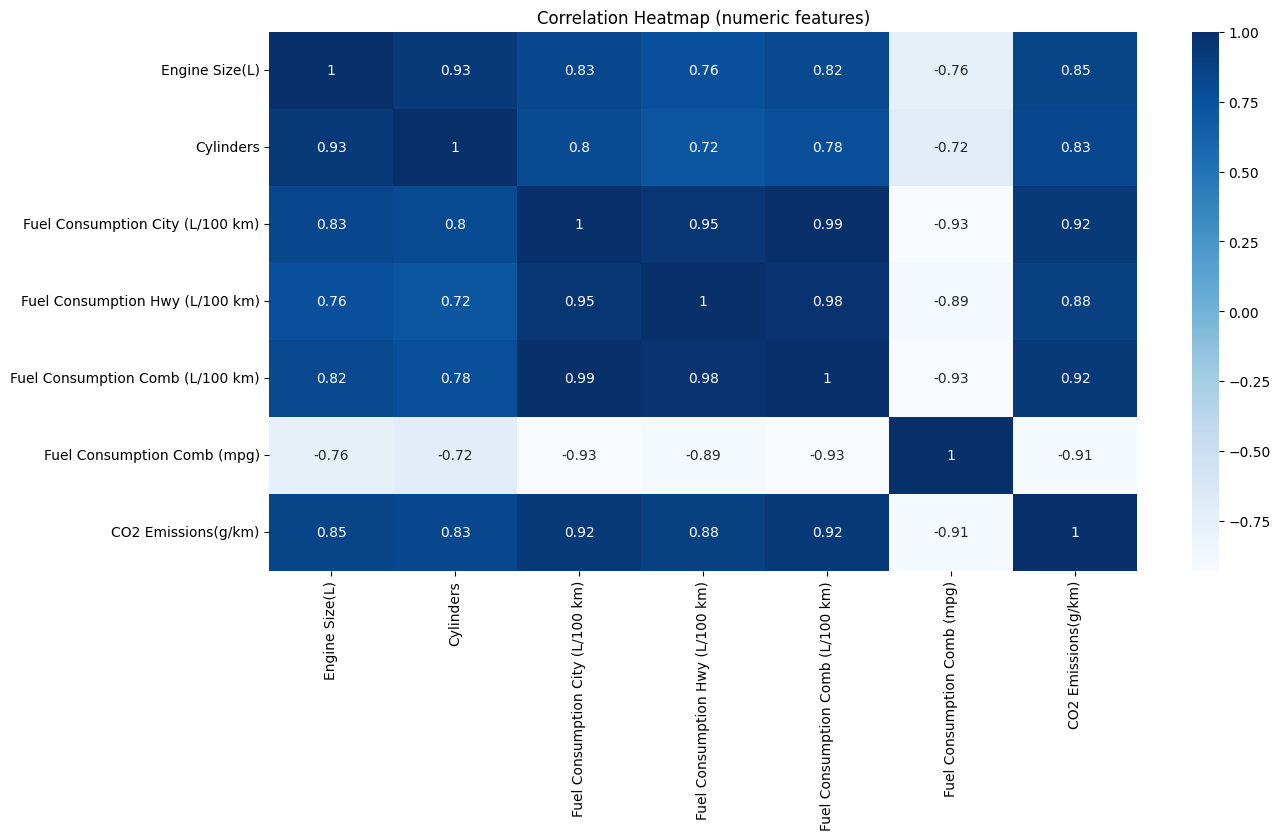

In [ ]:
numeric_cols = cars.select_dtypes(include=np.number)

correlation = numeric_cols.corr()

print(correlation["CO2 Emissions(g/km)"].sort_values(ascending=False))

correlation = numeric_cols.corr()
plt.figure(figsize=(14,7))
sns.heatmap(correlation, cmap="Blues", annot=True)
plt.title("Correlation Heatmap (numeric features)")
plt.show()

Q4 — Visual Analysis

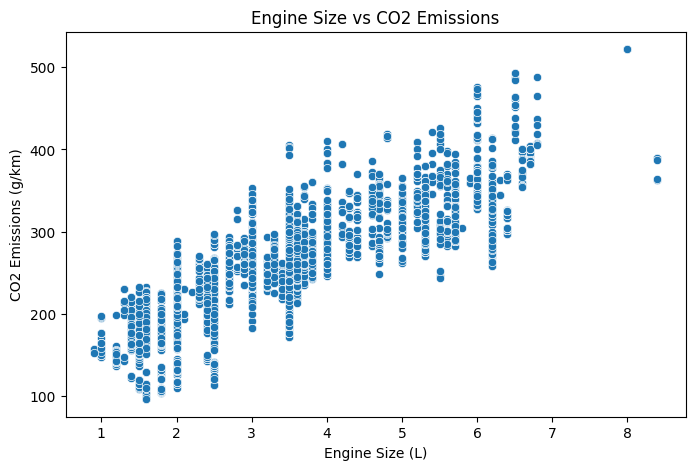

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=cars,
    x="Engine Size(L)",
    y="CO2 Emissions(g/km)"
)

plt.title("Engine Size vs CO2 Emissions")
plt.xlabel("Engine Size (L)")
plt.ylabel("CO2 Emissions (g/km)")
plt.show()

### Observation — Q4: Engine Size vs CO₂

- The scatter plot shows the relationship between engine size and CO₂ emissions.
- The overall pattern is upward: larger-engine vehicles tend to have higher CO₂ emissions.
- However, vehicles with similar engine sizes can still have different emission levels, showing that engine size alone does not explain all of the variation.
- This supports keeping `Engine Size(L)` as a candidate numerical predictor while also considering fuel consumption and other vehicle characteristics.

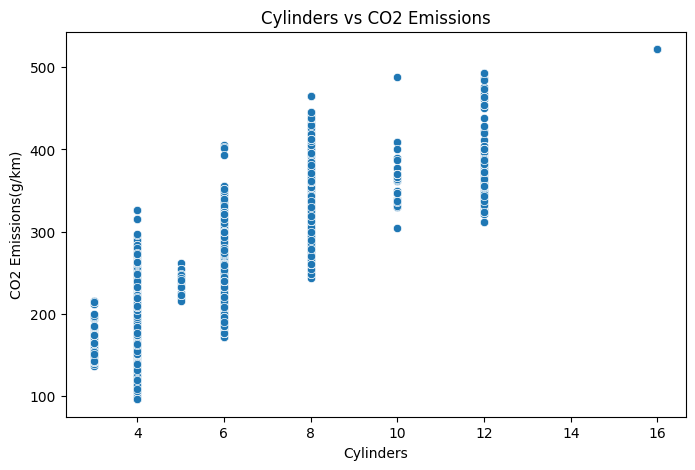

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=cars,
    x="Cylinders",
    y="CO2 Emissions(g/km)"
)

plt.title("Cylinders vs CO2 Emissions")
plt.show()

### Observation — Q4: Cylinders vs CO₂

- The plot shows an overall positive association between the number of cylinders and CO₂ emissions.
- Vehicles with more cylinders generally tend to have higher emissions, although there is variation within the same cylinder count.
- This suggests that `Cylinders` is another useful numerical candidate for the regression model, but it should be evaluated together with engine size and fuel consumption.

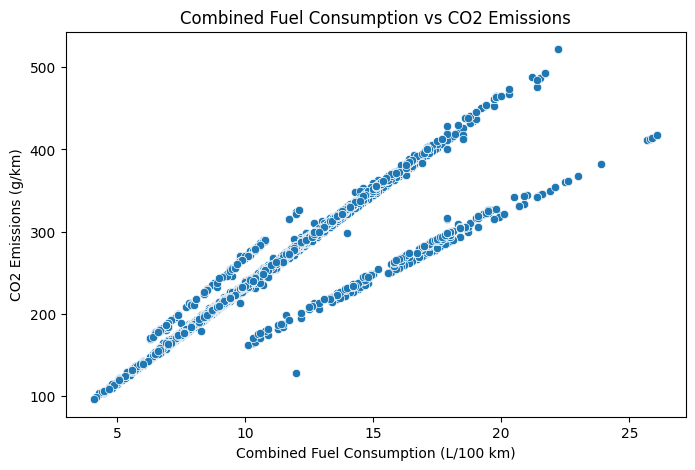

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=cars,
    x="Fuel Consumption Comb (L/100 km)",
    y="CO2 Emissions(g/km)"
)

plt.title("Combined Fuel Consumption vs CO2 Emissions")
plt.xlabel("Combined Fuel Consumption (L/100 km)")
plt.ylabel("CO2 Emissions (g/km)")
plt.show()

### Observation — Q4: Combined Fuel Consumption vs CO₂

- Combined fuel consumption has one of the strongest relationships with CO₂ emissions in the dataset.
- The correlation is approximately **0.918**, and the scatter plot shows a clear upward pattern: vehicles consuming more fuel per 100 km generally emit more CO₂ per km.
- This makes `Fuel Consumption Comb (L/100 km)` a strong candidate predictor.
- However, there is an important modeling consideration: fuel consumption is very closely related to the outcome itself. Therefore, we should distinguish between a **prediction model that is allowed to use measured fuel consumption** and a **vehicle-design model that predicts emissions from specifications before fuel consumption is known**.

## Q5 — Comparison Across Vehicle and Fuel Categories

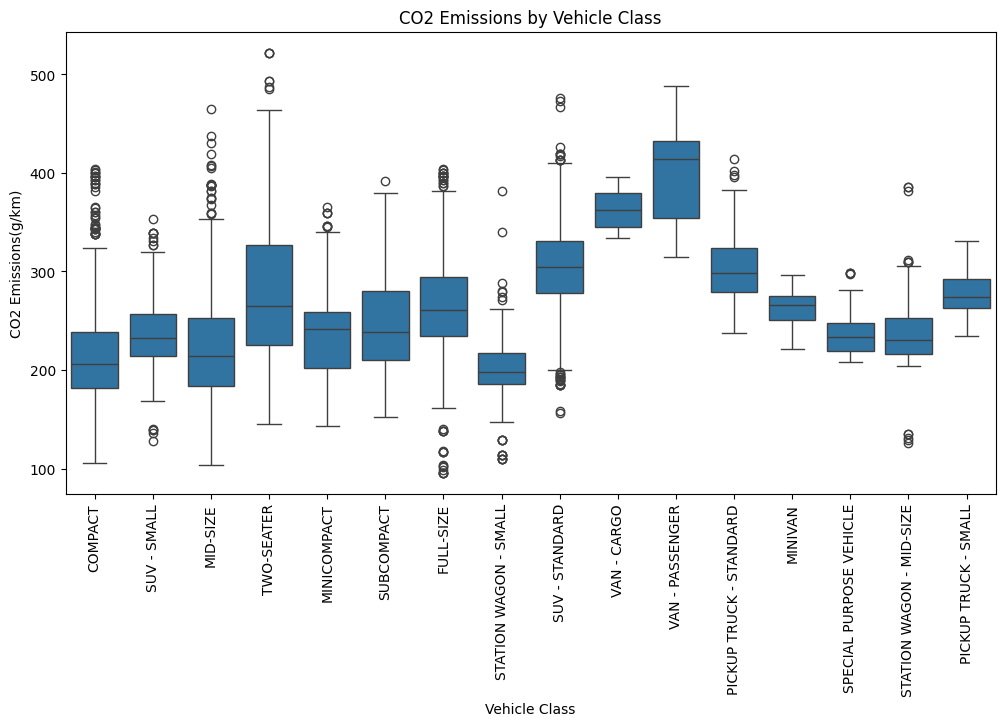

In [ ]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=cars,
    x="Vehicle Class",
    y="CO2 Emissions(g/km)"
)

plt.xticks(rotation=90)
plt.title("CO2 Emissions by Vehicle Class")
plt.show()

### Observation — Q5: Vehicle Class

- The boxplot compares the distribution of CO₂ emissions across vehicle classes.
- Differences in medians and spread indicate that vehicle class is associated with different emission profiles.
- There is also overlap between classes, so vehicle class alone cannot fully explain CO₂ emissions.
- `Vehicle Class` is therefore a useful **categorical predictor**, which can later be represented using one-hot encoding.

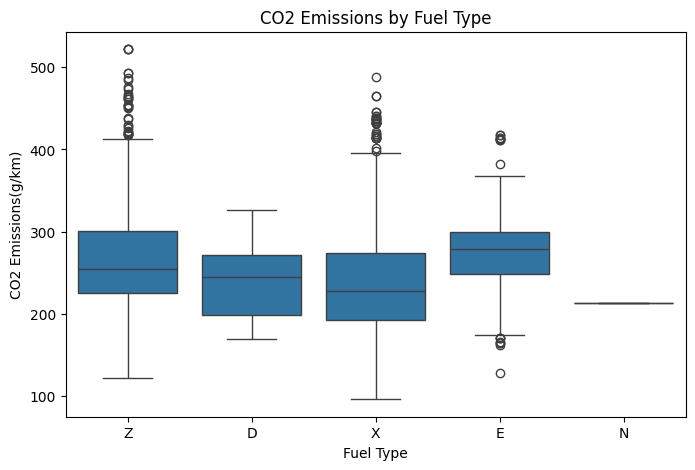

X = Regular gasoline
Z = Premium gasoline
D = Diesel
E = Ethanol (E85)
N = Natural gas


In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=cars,
    x="Fuel Type",
    y="CO2 Emissions(g/km)"
)

plt.title("CO2 Emissions by Fuel Type")
plt.show()

print("""X = Regular gasoline
Z = Premium gasoline
D = Diesel
E = Ethanol (E85)
N = Natural gas""")

### Observation — Q5: Fuel Type

- The boxplot compares CO₂ emission distributions across the five fuel types.
- The fuel codes are: **X = Regular gasoline, Z = Premium gasoline, D = Diesel, E = Ethanol (E85), N = Natural gas**.
- Differences between fuel categories suggest that fuel type may contribute information beyond the numerical engine characteristics.
- However, fuel type can be associated with different vehicle configurations, so its effect should be interpreted together with engine size, cylinders, vehicle class and fuel consumption.
- `Fuel Type` is a categorical feature and will require encoding before regression.

## Q6 — Unusual / Extreme Emission Records

In [ ]:
cars.sort_values(
    "CO2 Emissions(g/km)",
    ascending=False
).head(10)

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
6640,BUGATTI,Chiron,TWO-SEATER,8.0,16,AM7,Z,26.8,16.6,22.2,13,522
5575,BUGATTI,Chiron,TWO-SEATER,8.0,16,AM7,Z,26.8,16.6,22.2,13,522
4509,BUGATTI,CHIRON,TWO-SEATER,8.0,16,AM7,Z,26.8,16.6,22.2,13,522
7059,LAMBORGHINI,Aventador Roadster,TWO-SEATER,6.5,12,AM7,Z,26.6,15.8,21.7,13,493
6046,LAMBORGHINI,Aventador Roadster,TWO-SEATER,6.5,12,AM7,Z,26.6,15.8,21.7,13,493
349,FORD,E350 WAGON,VAN - PASSENGER,6.8,10,A5,X,23.9,17.8,21.2,13,488
6045,LAMBORGHINI,Aventador Coupe,TWO-SEATER,6.5,12,AM7,Z,26.3,15.6,21.5,13,487
7058,LAMBORGHINI,Aventador Coupe,TWO-SEATER,6.5,12,AM7,Z,26.2,15.5,21.4,13,485
2971,MERCEDES-BENZ,AMG G 65,SUV - STANDARD,6.0,12,AS7,Z,24.3,17.9,21.4,13,476
5126,MERCEDES-BENZ,AMG G 65,SUV - STANDARD,6.0,12,A7,Z,22.2,18.0,20.3,14,473


### Observation — Q6: Highest-emission records

- These are the **10 records with the highest recorded CO₂ emissions**; they are not automatically data errors.
- Several high-emission records belong to large-engine/high-cylinder configurations, so their high values may be consistent with their vehicle characteristics.
- Some records are repeated because the dataset contains exact duplicates. Therefore, we should be careful not to interpret repeated rows as 10 independent vehicle models.
- These observations are useful for understanding the upper end of the emission distribution, but an extreme value should only be considered problematic if it is inconsistent with comparable vehicle characteristics.

In [ ]:
cars.sort_values(
    "CO2 Emissions(g/km)",
    ascending=True
).head(10)

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
3824,HYUNDAI,IONIQ BLUE,FULL-SIZE,1.6,4,AM6,X,4.2,4.0,4.1,69,96
6950,HYUNDAI,IONIQ Blue,FULL-SIZE,1.6,4,AM6,X,4.2,4.0,4.1,69,96
4900,HYUNDAI,IONIQ BLUE,FULL-SIZE,1.6,4,AM6,X,4.2,4.0,4.1,69,96
5931,HYUNDAI,IONIQ Blue,FULL-SIZE,1.6,4,AM6,X,4.2,4.0,4.1,69,96
6949,HYUNDAI,IONIQ,FULL-SIZE,1.6,4,AM6,X,4.2,4.2,4.2,67,99
4899,HYUNDAI,IONIQ,FULL-SIZE,1.6,4,AM6,X,4.3,4.4,4.3,66,102
3823,HYUNDAI,IONIQ,FULL-SIZE,1.6,4,AM6,X,4.3,4.4,4.4,64,103
3229,TOYOTA,PRIUS,MID-SIZE,1.8,4,AV,X,4.4,4.6,4.5,63,104
5930,HYUNDAI,IONIQ,FULL-SIZE,1.6,4,AM6,X,4.3,4.4,4.3,66,104
6442,TOYOTA,Prius,MID-SIZE,1.8,4,AV,X,4.4,4.6,4.4,64,105


### Observation — Q6: Lowest-emission records

- These are the **10 records with the lowest recorded CO₂ emissions**.
- Many of the low-emission records are associated with relatively low fuel consumption and smaller engine configurations.
- As with the high-emission group, repeated records can appear because of exact duplicates, so the list should be interpreted as records rather than necessarily 10 unique vehicles.
- These observations help us understand which vehicle configurations are associated with the lower end of the CO₂ distribution.

In [ ]:
high_emitters = cars.sort_values(
    "CO2 Emissions(g/km)",
    ascending=False
).head(10)

low_emitters = cars.sort_values(
    "CO2 Emissions(g/km)",
    ascending=True
).head(10)

print("Average CO2 of 10 highest emitters:",
      high_emitters["CO2 Emissions(g/km)"].mean())

print("Average CO2 of 10 lowest emitters:",
      low_emitters["CO2 Emissions(g/km)"].mean())

Average CO2 of 10 highest emitters: 496.1
Average CO2 of 10 lowest emitters: 100.1


### Observation — Q6: Extreme-group comparison

- The 10 highest-emission records have an average CO₂ emission of **496.1 g/km**, while the 10 lowest-emission records average **100.1 g/km**.
- This large difference confirms that the dataset contains very different emission profiles.
- The next step is to compare engine size, cylinders and fuel consumption between these groups rather than treating the extreme values as errors automatically.

In [ ]:
extreme_vehicles = pd.concat([
    high_emitters.assign(Group="Highest Emitters"),
    low_emitters.assign(Group="Lowest Emitters")
])

extreme_vehicles[
    [
        "Group",
        "Make",
        "Model",
        "Vehicle Class",
        "Engine Size(L)",
        "Cylinders",
        "Fuel Type",
        "Fuel Consumption Comb (L/100 km)",
        "CO2 Emissions(g/km)"
    ]
]

,Group,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Fuel Type,Fuel Consumption Comb (L/100 km),CO2 Emissions(g/km)
6640,Highest Emitters,BUGATTI,Chiron,TWO-SEATER,8.0,16,Z,22.2,522
5575,Highest Emitters,BUGATTI,Chiron,TWO-SEATER,8.0,16,Z,22.2,522
4509,Highest Emitters,BUGATTI,CHIRON,TWO-SEATER,8.0,16,Z,22.2,522
7059,Highest Emitters,LAMBORGHINI,Aventador Roadster,TWO-SEATER,6.5,12,Z,21.7,493
6046,Highest Emitters,LAMBORGHINI,Aventador Roadster,TWO-SEATER,6.5,12,Z,21.7,493
349,Highest Emitters,FORD,E350 WAGON,VAN - PASSENGER,6.8,10,X,21.2,488
6045,Highest Emitters,LAMBORGHINI,Aventador Coupe,TWO-SEATER,6.5,12,Z,21.5,487
7058,Highest Emitters,LAMBORGHINI,Aventador Coupe,TWO-SEATER,6.5,12,Z,21.4,485
2971,Highest Emitters,MERCEDES-BENZ,AMG G 65,SUV - STANDARD,6.0,12,Z,21.4,476
5126,Highest Emitters,MERCEDES-BENZ,AMG G 65,SUV - STANDARD,6.0,12,Z,20.3,473


### Observation — Q6: Characteristics of extreme records

- Comparing the highest- and lowest-emission groups helps identify the vehicle characteristics associated with the extremes.
- We expect engine size, cylinders and combined fuel consumption to be especially informative because they have strong numerical relationships with CO₂.
- This analysis is descriptive; it does not by itself establish causation.
- The findings from Q3–Q6 will now guide the feature-selection and preprocessing decisions for the regression model.

## Q7 — Preparing Features for Regression

### Modeling approach

We will prepare the data for two regression scenarios:

1. **Model A — Specification-only:** Engine Size, Cylinders, Vehicle Class, Transmission and Fuel Type.
2. **Model B — Specification + Fuel Consumption:** the same features plus `Fuel Consumption Comb (L/100 km)`.

This comparison separates two questions:
- Can CO₂ emissions be estimated from vehicle specifications?
- How much does prediction improve when fuel consumption is also known?

In linear regression, the model learns a coefficient (weight) for each predictor. Categorical variables cannot be entered as raw text, so they will be converted using one-hot encoding.


In [ ]:
# Use the de-duplicated dataset for modeling so identical records
# do not receive additional weight.

model_data = cars_no_duplicates.copy()

target = "CO2 Emissions(g/km)"

spec_numeric_features = [
    "Engine Size(L)",
    "Cylinders"
]

spec_categorical_features = [
    "Vehicle Class",
    "Transmission",
    "Fuel Type"
]

consumption_feature = [
    "Fuel Consumption Comb (L/100 km)"
]

print("Rows available for modeling:", len(model_data))
print("Target:", target)
print("Specification numerical features:", spec_numeric_features)
print("Specification categorical features:", spec_categorical_features)
print("Additional consumption feature:", consumption_feature)


### Observation — Q7: Feature preparation

- The modeling dataset contains **6,282 rows** after removing exact duplicates.
- `Engine Size(L)`, `Cylinders`, and `Fuel Consumption Comb (L/100 km)` are **numerical** features.
- `Vehicle Class`, `Transmission`, and `Fuel Type` are **categorical** features and require one-hot encoding.
- The regression model will learn the coefficients (weights) from the training data rather than assigning them manually.
- We will compare a specification-only model with a model that also includes fuel consumption.


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


### Q7.1 — Separate predictors and target

For regression:

- `X` = input features used to estimate CO₂
- `y` = `CO2 Emissions(g/km)`, the target variable


In [ ]:
# Use all features required for the consumption-assisted model.
X = model_data[
    spec_numeric_features +
    spec_categorical_features +
    consumption_feature
]

y = model_data[target]

print("X shape:", X.shape)
print("y shape:", y.shape)


### Observation — Q7.1

The target is `CO2 Emissions(g/km)`. The predictors contain both numerical and categorical information. The categorical variables will be encoded inside the modeling pipeline so that the same preprocessing is applied consistently to training and test data.


### Q7.2 — Train/test split

We reserve 20% of the observations for testing. The test data is not used to fit the regression model, allowing us to evaluate how well the model performs on unseen vehicles.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])


### Observation — Q7.2

The data is divided into training and testing sets using a fixed random state of 42. The training set is used to learn the regression coefficients, while the test set is reserved for evaluating model performance.


### Q7.3 — Preprocessing and encoding

`OneHotEncoder` converts categorical variables into numerical indicator columns. Numerical variables are passed through without changing their units.

A `Pipeline` will keep preprocessing and regression together, reducing the risk of applying different transformations to training and test data.


# Q8 — Develop an Interpretable Regression Model

## Model A — Specification-only regression

Model A estimates CO₂ using vehicle specifications:

- Engine Size
- Cylinders
- Vehicle Class
- Transmission
- Fuel Type

This model is useful when the objective is to estimate emissions from vehicle characteristics without relying on fuel consumption.


In [ ]:
spec_features = [
    "Engine Size(L)",
    "Cylinders",
    "Vehicle Class",
    "Transmission",
    "Fuel Type"
]

X_spec = model_data[spec_features]

X_spec_train, X_spec_test, y_spec_train, y_spec_test = train_test_split(
    X_spec,
    y,
    test_size=0.20,
    random_state=42
)

spec_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            ["Vehicle Class", "Transmission", "Fuel Type"]
        ),
        (
            "numerical",
            "passthrough",
            ["Engine Size(L)", "Cylinders"]
        )
    ]
)

spec_model = Pipeline(
    steps=[
        ("preprocessor", spec_preprocessor),
        ("regressor", LinearRegression())
    ]
)

spec_model.fit(X_spec_train, y_spec_train)

spec_pred = spec_model.predict(X_spec_test)

spec_mae = mean_absolute_error(y_spec_test, spec_pred)
spec_rmse = np.sqrt(mean_squared_error(y_spec_test, spec_pred))
spec_r2 = r2_score(y_spec_test, spec_pred)

X_spec_test_transformed = spec_model.named_steps["preprocessor"].transform(
    X_spec_test
)

n_spec = X_spec_test_transformed.shape[0]
p_spec = X_spec_test_transformed.shape[1]

adjusted_r2_spec = 1 - (
    (1 - spec_r2) * (n_spec - 1) /
    (n_spec - p_spec - 1)
)

print("Specification-only model")
print("------------------------")
print("MAE          :", round(spec_mae, 2), "g/km")
print("RMSE         :", round(spec_rmse, 2), "g/km")
print("R²           :", round(spec_r2, 4))
print("Adjusted R²  :", round(adjusted_r2_spec, 4))
print("Predictors   :", p_spec)
print("Observations :", n_spec)


### Observation — Q8: Model A

The specification-only model achieves an **MAE of 17.29 g/km**, an **RMSE of 22.52 g/km**, an **R² of 0.8595**, and an **Adjusted R² of 0.8538**.

This indicates that vehicle specifications alone explain a substantial portion of the variation in CO₂ emissions. The model is therefore useful as an interpretable baseline for estimating emissions from vehicle characteristics.


## Model B — Specification + Fuel Consumption

Model B adds `Fuel Consumption Comb (L/100 km)` to the specification features.

This model tests how much predictive information is added when fuel consumption is known.


In [ ]:
full_features = [
    "Engine Size(L)",
    "Cylinders",
    "Vehicle Class",
    "Transmission",
    "Fuel Type",
    "Fuel Consumption Comb (L/100 km)"
]

X_full = model_data[full_features]

X_full_train, X_full_test, y_full_train, y_full_test = train_test_split(
    X_full,
    y,
    test_size=0.20,
    random_state=42
)

full_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            ["Vehicle Class", "Transmission", "Fuel Type"]
        ),
        (
            "numerical",
            "passthrough",
            [
                "Engine Size(L)",
                "Cylinders",
                "Fuel Consumption Comb (L/100 km)"
            ]
        )
    ]
)

full_model = Pipeline(
    steps=[
        ("preprocessor", full_preprocessor),
        ("regressor", LinearRegression())
    ]
)

full_model.fit(X_full_train, y_full_train)

full_pred = full_model.predict(X_full_test)

full_mae = mean_absolute_error(y_full_test, full_pred)
full_rmse = np.sqrt(mean_squared_error(y_full_test, full_pred))
full_r2 = r2_score(y_full_test, full_pred)

X_full_test_transformed = full_model.named_steps["preprocessor"].transform(
    X_full_test
)

n_full = X_full_test_transformed.shape[0]
p_full = X_full_test_transformed.shape[1]

adjusted_r2_full = 1 - (
    (1 - full_r2) * (n_full - 1) /
    (n_full - p_full - 1)
)

print("Specification + Fuel Consumption model")
print("--------------------------------------")
print("MAE          :", round(full_mae, 2), "g/km")
print("RMSE         :", round(full_rmse, 2), "g/km")
print("R²           :", round(full_r2, 4))
print("Adjusted R²  :", round(adjusted_r2_full, 4))
print("Predictors   :", p_full)
print("Observations :", n_full)


### Observation — Q8: Model B

After adding combined fuel consumption, the model achieves an **MAE of 3.30 g/km**, an **RMSE of 6.01 g/km**, an **R² of 0.9900**, and an **Adjusted R² of 0.9896**.

The large improvement compared with Model A shows that fuel consumption contains substantial additional information for estimating CO₂ emissions in this dataset.


# Q9 — Assess Model Performance

We evaluate both models using:

- **MAE:** average absolute prediction error in g/km.
- **RMSE:** prediction error that gives greater weight to larger errors.
- **R²:** proportion of variation in CO₂ explained by the model.
- **Adjusted R²:** R² adjusted for the number of predictors used by the regression.


In [ ]:
results = pd.DataFrame({
    "Model": [
        "Specification-only",
        "Specification + Fuel Consumption"
    ],
    "MAE (g/km)": [
        spec_mae,
        full_mae
    ],
    "RMSE (g/km)": [
        spec_rmse,
        full_rmse
    ],
    "R²": [
        spec_r2,
        full_r2
    ],
    "Adjusted R²": [
        adjusted_r2_spec,
        adjusted_r2_full
    ]
})

results


### Observation — Q9: Model comparison

- The specification-only model has an **MAE of 17.29 g/km** and an **RMSE of 22.52 g/km**.
- Adding fuel consumption reduces the **MAE to 3.30 g/km** and the **RMSE to 6.01 g/km**.
- R² increases from **0.8595 to 0.9900**, while Adjusted R² increases from **0.8538 to 0.9896**.
- The small difference between R² and Adjusted R² for Model B indicates that its high explanatory performance remains after accounting for the number of encoded predictors.
- The results show that fuel consumption provides substantial predictive information. This should be interpreted as a strong association and predictive relationship, not by itself as proof of causation.


### Q9.1 — Actual vs Predicted CO₂ for Model B

The following plot compares actual test-set emissions with the emissions predicted by the consumption-assisted model.


In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_full_test,
    full_pred,
    alpha=0.5
)

plt.xlabel("Actual CO₂ Emissions (g/km)")
plt.ylabel("Predicted CO₂ Emissions (g/km)")
plt.title("Model B: Actual vs Predicted CO₂ Emissions")

plt.plot(
    [y_full_test.min(), y_full_test.max()],
    [y_full_test.min(), y_full_test.max()],
    linestyle="--"
)

plt.show()


### Observation — Q9.1

The predicted values should generally lie close to the diagonal reference line. Points close to the line represent small prediction errors, while points farther from the line represent larger errors.

The visual pattern, together with the **MAE of 3.30 g/km**, **RMSE of 6.01 g/km**, and **R² of 0.9900**, indicates that the consumption-assisted model estimates the test-set CO₂ values closely.


# Q10 — Key Factors Influencing CO₂ Emissions

The earlier correlation analysis and the regression comparison provide complementary evidence about the variables associated with CO₂ emissions.


### Observation — Q10: Key factors and emission-reduction implications

- **Fuel consumption** shows the strongest numerical relationship with CO₂ emissions in this dataset and provides substantial additional predictive information in the regression model.
- **Engine size and cylinder count** also show strong positive relationships with CO₂ emissions.
- **Vehicle class, transmission and fuel type** provide additional categorical information and are represented in the regression through one-hot encoding.
- The highest-emission records were associated with large engines, high cylinder counts and high fuel consumption, while the lowest-emission records had much lower consumption and smaller vehicle configurations.
- For prediction, fuel consumption is highly informative. For decisions made before fuel consumption is known, the specification-only model provides a more direct view of the information contained in vehicle characteristics.
- These findings can support emission-reduction efforts by highlighting **fuel efficiency, energy consumption and vehicle design characteristics** as areas for investigation.
- The analysis identifies strong associations and predictive relationships; it does not establish causation from this dataset alone.


## Final Case Study Conclusion

The analysis shows that vehicle specifications provide a useful baseline for estimating CO₂ emissions, while adding combined fuel consumption substantially improves predictive performance. The specification-only model explains about **85.95%** of the variation in CO₂, whereas the consumption-assisted model explains about **99.00%**.

The results therefore support two complementary uses: vehicle specifications can help understand emissions before fuel consumption is known, while fuel consumption is particularly useful when the goal is accurate CO₂ prediction. The strongest numerical relationships are associated with fuel consumption, followed by engine size and cylinder count.
